<a href="https://colab.research.google.com/github/mzsmarcos/Analytics/blob/main/Analise_RFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}
0
Verificando preços nulos ou menores que zero:
       InvoiceNo StockCode                          Description  Quantity  \
9302      537197     22841         ROUND CAKE TIN VINTAGE GREEN         1   
33576     539263     22580         ADVENT CALENDAR GINGHAM SACK         4   
40089     539722     22423             REGENCY CAKESTAND 3 TIER        10   
47068     540372     22090              PAPER BUNTING RETROSPOT        24   
47070     540372     22553               PLASTERS IN TIN SKULLS        24   
56674     541109     22168        ORGANISER WOOD ANTIQUE WHITE          1   
86789     543599    84535B         FAIRY CAKES NOTEBOOK A6 SIZE        16   
130188    547417     22062  CERAMIC BOWL WITH LOVE HEART DESIGN        36   
139453    548318     22055   MINI CAKE STAND  HANGING STRAWBERY         5   
145208    548871     22162          HEART GARLAND RUSTIC PADDED         2   
157042    550188     22636   CHILDS BREAKFAST SE

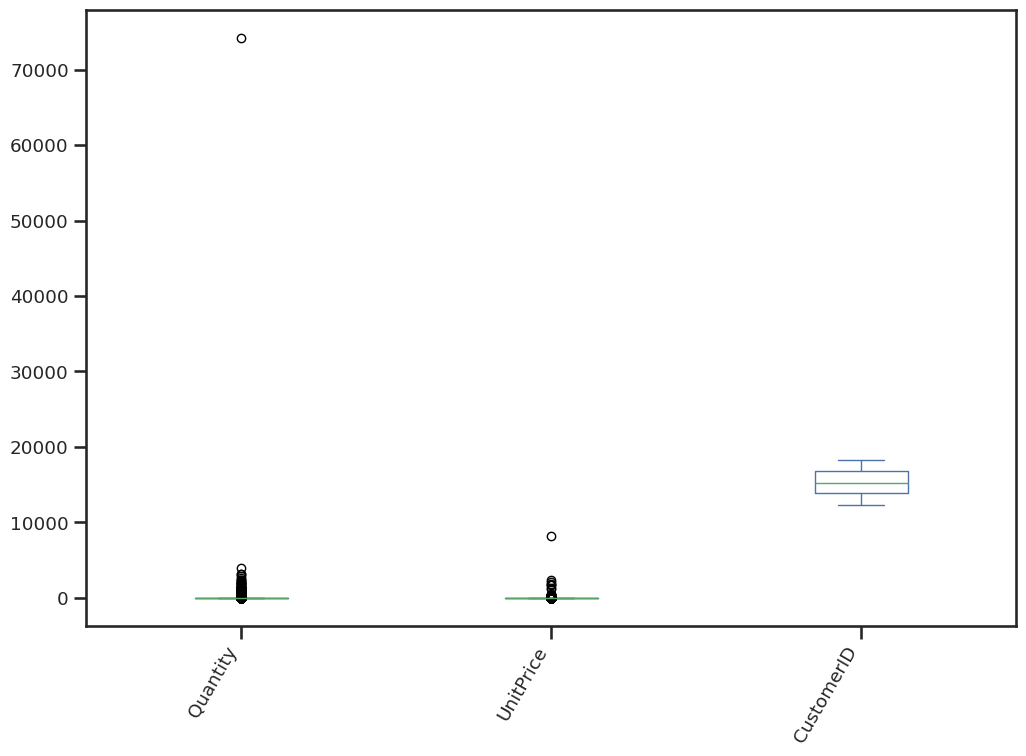

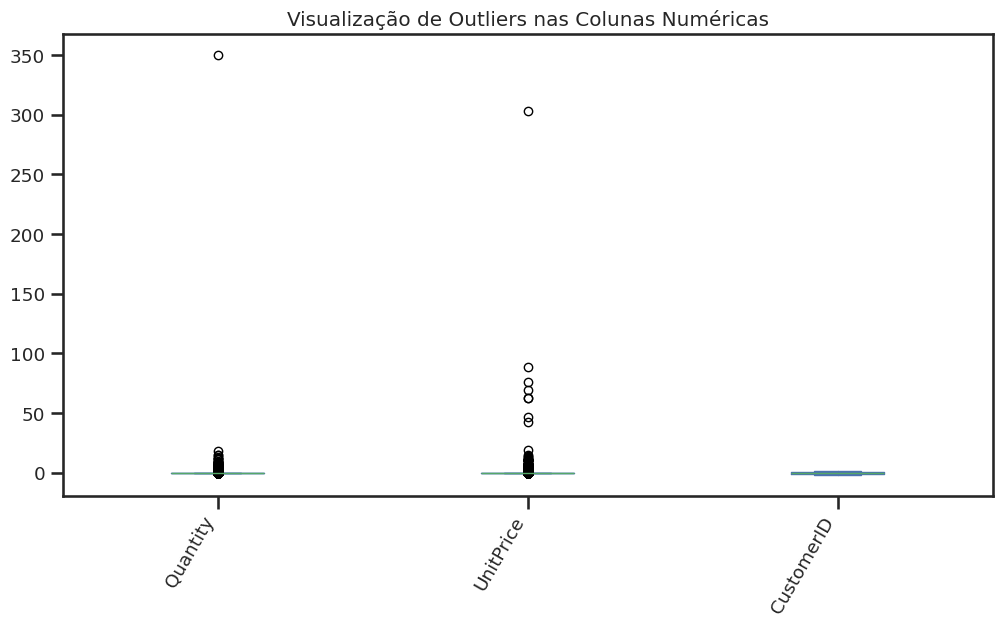

Shape antes da remoção: (128930, 8)
Shape depois da remoção: (128928, 8)
A última data de compra é: 2011-05-12 18:13:00


     InvoiceNo            InvoiceDate  TotalSale
0       536365  [2010-12-01 08:26:00]     139.12
1       536366  [2010-12-01 08:28:00]      22.20
2       536367  [2010-12-01 08:34:00]     278.73
3       536368  [2010-12-01 08:34:00]      70.05
4       536369  [2010-12-01 08:35:00]      17.85
...        ...                    ...        ...
6491    553007  [2011-05-12 16:50:00]     635.66
6492    553008  [2011-05-12 16:52:00]     191.44
6493    553009  [2011-05-12 16:52:00]     373.20
6494    553011  [2011-05-12 17:03:00]     309.05
6495    553012  [2011-05-12 18:13:00]     392.55

[6496 rows x 3 columns]
     InvoiceNo         InvoiceDate  Recency
0       536365 2010-12-01 08:26:00      162
1       536366 2010-12-01 08:28:00      162
2       536367 2010-12-01 08:34:00      162
3       536368 2010-12-01 08:34:00      162
4       536369 2010-12-01 08:35:00      162
...        ...                 ...      ...
6491    553007 2011-05-12 16:50:00        0
6492    553008 2011-05-12 16:52:00 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
## **Contexto**

# Uma empresa do ramo de e-commerce precisa levantar os indicadores de recência, frequência e ticket médio (RFM) dos seus clientes.

# A saber RFM:

# - R (Recency): Tempo que o cliente realizou a última compra (em dias)
# - F (Frequency): Quantidade de compras realizadas pelo cliente
# - M (Monetary): Valor do ticket médio gasto pelo cliente

# Onde ticket médio = média do total gasto por pedido para cada cliente.

# Para isso, forneceu uma base de dados (arquivo csv) para que seja construído um código em Python que gera um output também csv, porém contendo apenas a identificação do cliente e métricas RFM.

!pip install sidetable # facilita a análise exploratória de dados (EDA) ao fornecer resumos rápidos de tabelas, como contagem de valores, percentuais e identificação de valores ausentes.
!pip install ydata-profiling # antigo pandas-profiling uma ferramenta que gera relatórios automáticos para análise exploratória de dados.

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sidetable
from ydata_profiling import ProfileReport
import missingno as msno
from ipywidgets import interact, widgets

from sklearn import datasets
from sklearn.preprocessing import scale, minmax_scale, power_transform

sns.set_theme(
    context='talk',
    style='ticks',
    font_scale=.8,
    rc={
        'figure.figsize': (12,8)
    }
)

def list_attributes(obj):
    """Lista atributos e funções de um objeto"""
    return [attr for attr in obj.__dir__() if not attr.startswith('_')]

# **Etapa 01)**  Leitura do arquivo e inspeção os dados

!pip install chardet # biblioteca usada para detectar automaticamente a codificação de arquivos de texto

import chardet

# Detectar a codificação
with open('/content/data.csv', 'rb') as f:
    sample = f.read(20480)  # Lê os primeiros 20 KB
    result = chardet.detect(sample)

print(result)

df = pd.read_csv('/content/data.csv', encoding='latin1')
df.head()

df.profile_report() # comando usado para gerar um relatório automático de análise exploratória de dados com a biblioteca ydata-profiling

# **Etapa 02)** Remoção de valores faltantes na identificação do cliente

# Identificar,  mostrar e somar valores nulos
df_missing = (
    df.isna().sum()
    .to_frame('missing_count')
    .join((df.isna().sum() / df.shape[0]).to_frame('missing_pct'))
    .sort_values('missing_count', ascending=False)
)

df_missing.style.format('{:.2%}', subset=['missing_pct'])

# Mostrando as linhas com valores faltantes como um todo:
df[df.isna().any(axis=1)]

# Mostrando as linhas com valores faltantes na coluna CustomerID
df[df.CustomerID.isna()]

# Removendo valores faltantes na identificação do cliente
df = df.dropna(subset=['CustomerID'])
print(df.CustomerID.isna().sum()) # confirma se ainda existem valores ausentes na coluna

# **Etapa 03)** Preços unitários e quantidade de produtos iguais ou
# inferior a 0

# Verificar valores nulos ou menores que zero em preços
print("Verificando preços nulos ou menores que zero:")
print(df[df['UnitPrice'].isnull() | (df['UnitPrice'] <= 0)])

# Filtrar o dataset
df = df[df['UnitPrice'] > 0]
print("Dataset após remoção de preços inválidos:")
print(df)

# Verificar valores nulos ou menores que zero em quantidade
print("Verificando quantidade nula ou menor que zero:")
print(df[df['Quantity'].isnull() | (df['Quantity'] <= 0)])

# Filtrar o dataset
df = df[df['Quantity'] > 0]
print("Dataset após remoção de quantidades inválidas:")
print(df)

# **Etapa 04)** Verifique se existem linhas duplicadas

# Identificar valores duplicados
df[df.duplicated(keep=False)]

# Identificar quantos valores duplicados há em cada duplicata
(
    df
    .groupby(df.columns.tolist(), dropna=False)
    .size()
    .to_frame('n_duplicates')
    .query('n_duplicates>1')
    .sort_values('n_duplicates', ascending=False)
    .head(5)
)

# Remover valores duplicados
df.drop_duplicates()

# **Etapa 05)** Tipos de dados da coluna

# Verificar os tipos dos dados que constam no dataset
df.dtypes

# Converte a coluna CustomerID para inteiro
df['CustomerID'] = df['CustomerID'].astype('int')

# Converte a coluna InvoiceDate para datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Verificar os tipos dos dados que constam no dataset após correção
df.dtypes

# **Etapa 06)** Tratando os outliers

# Visualizando outliers
df.plot.box()
plt.xticks(rotation=60, ha='right');

# Selecionando apenas as colunas numéricas
numeric_columns = df.select_dtypes(include=['number'])

# Padronizando os dados numéricos
scaled_df = numeric_columns.apply(scale)

# Criando o boxplot para visualização dos outliers
scaled_df.plot.box(figsize=(12, 6))
plt.xticks(rotation=60, ha='right')
plt.title("Visualização de Outliers nas Colunas Numéricas")
plt.show()

# Removendo os outliers extremos em que a quantidade do item na compra é superior a 10.000, e o preço unitário é maior que 5.000.

# Definindo os limites para remoção de outliers
quantity_threshold = 10000
unitprice_threshold = 5000

# Removendo as linhas com outliers extremos
df_filtered = df[(df['Quantity'] <= quantity_threshold) & (df['UnitPrice'] <= unitprice_threshold)]

# Exibindo o DataFrame sem os outliers
print(f"Shape antes da remoção: {df.shape}")
print(f"Shape depois da remoção: {df_filtered.shape}")

# **Etapa 07)** Crie uma coluna adicional com o preço
# total da compra

df['TotalSale'] = df['Quantity'] * df['UnitPrice']
df.head()

# **Etapa 08) Última data > data da última compra no dataset como um todo**

# Identifica e define a última data de compra
last_data_sale = df['InvoiceDate'].max()
print(f"A última data de compra é: {last_data_sale}")

# **Etapa 09) Plotando gráficos**

# Top 10 países com maior valor em vendas
import plotly.express as px

# 1. Agrupar por país e somar as vendas
total_vendas_por_pais = df.groupby('Country')['TotalSale'].sum()

# 2. Ordenar os países por vendas em ordem decrescente e pegar os 10 primeiros
top_10_paises = total_vendas_por_pais.sort_values(ascending=False).head(10).reset_index()

# 3. Criar o gráfico interativo de barras com Plotly Express
fig = px.bar(top_10_paises, x='Country', y='TotalSale',
             title='Top 10 Países por Valor de Vendas',
             labels={'TotalSale': 'Valor Total de Vendas'},  # Renomeia o rótulo do eixo y
             color='TotalSale',  # Adiciona cores às barras com base nos valores
             color_continuous_scale='viridis')  # Escolhe uma paleta de cores

# 4. Mostrar o gráfico
fig.show()

# Top 10 produtos mais vendidos

# 1. Agrupar por país e somar as vendas
total_vendas_por_produtos = df.groupby('Description')['TotalSale'].sum()

# 2. Ordenar os produtos por vendas em ordem decrescente e pegar os 10 primeiros
top_10_produtos = total_vendas_por_produtos.sort_values(ascending=False).head(10).reset_index()

# 3. Criar o gráfico interativo de barras com Plotly Express
fig = px.bar(top_10_produtos, x='Description', y='TotalSale',
             title='Top 10 Produtos por Valor de Vendas',
             labels={'TotalSale': 'Valor Total de Vendas'},  # Renomeia o rótulo do eixo y
             color='TotalSale',  # Adiciona cores às barras com base nos valores
             color_continuous_scale='viridis')  # Escolhe uma paleta de cores

# 4. Mostrar o gráfico
fig.show()

# Valor de venda total por mês

# 1. Extrair o mês e o ano da coluna 'InvoiceDate'
df['Mês'] = df['InvoiceDate'].dt.month
df['Ano'] = df['InvoiceDate'].dt.year

# 2. Agrupar por mês e ano e somar as vendas
total_vendas_por_mes = df.groupby(['Ano', 'Mês'])['TotalSale'].sum().reset_index()

# 3. Pivotear a tabela para o formato correto para o heatmap
total_vendas_pivot = total_vendas_por_mes.pivot(index='Ano', columns='Mês', values='TotalSale')

# 4. Criar o gráfico de calor com Plotly Express
fig = px.imshow(total_vendas_pivot,
             labels=dict(color='Total de Vendas'),  # Renomeia o rótulo da barra de cores
             title='Total de Vendas por Mês e Ano',
             color_continuous_scale='viridis')  # Escolhe uma paleta de cores

# 5. Formatar os rótulos dos eixos para melhor visualização
fig.update_layout(xaxis_title='Mês', yaxis_title='Ano')
fig.update_xaxes(tickvals=list(range(1, 13)), ticktext=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                                                       'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# 6. Mostrar o gráfico
fig.show()

# Valor de venda total por mês e por país (considerando apenas os top 10)

# 5. Filtrar o DataFrame original para incluir apenas os top 10 países
df_top_10 = df[df['Country'].isin(top_10_paises['Country'])]

# 6. Agrupar por país, mês e ano e somar as vendas
total_vendas_mes_pais = df_top_10.groupby(['Ano', 'Mês', 'Country'])['TotalSale'].sum().reset_index()

# 7. Criar o gráfico de linha interativo com Plotly Express
fig = px.bar(total_vendas_mes_pais, x='Mês', y='TotalSale', color='Country',
             title='Valor de Vendas por Mês e País (Top 10)',
             labels={'TotalSale': 'Valor Total de Vendas'},  # Renomeia o rótulo do eixo y
             color_discrete_sequence=px.colors.qualitative.Set3)  # Escolhe uma paleta de cores

# 8. Formatar os rótulos dos eixos para melhor visualização
fig.update_layout(xaxis_title='Mês', yaxis_title='Valor Total de Vendas')
fig.update_xaxes(tickvals=list(range(1, 13)), ticktext=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                                                       'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# 9. Mostrar o gráfico
fig.show()

# Valor de venda total por mês e por país com gráfico de área

fig = px.area(total_vendas_mes_pais, x='Mês', y='TotalSale', color='Country',
             title='Evolução das Vendas por Mês e País (Top 10)',
             labels={'TotalSale': 'Valor Total de Vendas'},
             color_discrete_sequence=px.colors.qualitative.Set3)  # Adicionado log_y=True

# 8. Formatar os rótulos dos eixos para melhor visualização
fig.update_layout(xaxis_title='Mês', yaxis_title='Valor Total de Vendas')
fig.update_xaxes(tickvals=list(range(1, 13)), ticktext=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                                                       'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# 9. Mostrar o gráfico
fig.show()

# **Etapa 10) Cálculo do RFM **

# Agrupa por InvoiceNo e agrega as datas e o total do pedido
df_agrupado = df.groupby('InvoiceNo').agg(
    InvoiceDate=('InvoiceDate', 'unique'),  # Obtém datas únicas
    TotalSale=('TotalSale', 'sum')  # Soma os valores de TotalSale
).reset_index()

# Exibe o DataFrame resultante
print(df_agrupado)

# Agrupamento apenas pos cliente e cálculo da Recência -  diferença em dias da última compra do cliente e da última compra disponível no conjunto de dados

# Agrupa por cliente e encontra a última data de compra
df_last_purchase = df.groupby('InvoiceNo')['InvoiceDate'].max().reset_index()

# Calcula a recência em dias
df_last_purchase['Recency'] = (last_data_sale - df_last_purchase['InvoiceDate']).dt.days

# Exibe o DataFrame resultante
print(df_last_purchase)

# Cálculo da frequência - quantidade de compras feitas pelo cliente

# Agrupa por cliente e conta o número de compras
df_frequencia = df.groupby('InvoiceNo')['InvoiceNo'].count().reset_index(name='Frequencia')

# Exibe o DataFrame resultante
print(df_frequencia)

# Cálculo do Ticket Médio - valor médio das compras feitas pelo cliente

# Agrupa por cliente e calcula a média do valor total das compras
df_ticket_medio = df.groupby('InvoiceNo')['TotalSale'].mean().reset_index(name='Ticket_Medio')

# Exibe o DataFrame resultante
print(df_ticket_medio)

# Dataframe original tratado
df.head()

# Arquivo csv do dataframe original tratado
df.to_csv('df.csv', index=False) # gera o csv

from google.colab import files
files.download('df.csv') # faz o download do dataframe

# Dataframe de métricas do RFM

# Cria o DataFrame com as métricas
df_metricas_RFM = pd.concat([df_last_purchase['InvoiceNo'], df_last_purchase['Recency'],
                         df_frequencia['Frequencia'], df_ticket_medio['Ticket_Medio']], axis=1)

df_metricas_RFM.head()

# Top 10 clientes com maior Ticket Médio

# Ordena o DataFrame pelo Ticket Médio em ordem decrescente e pega os 10 primeiros
top_10_clientes = df_metricas_RFM.sort_values('Ticket_Medio', ascending=False).head(10)

# Cria o gráfico de barras interativo com Plotly Express
fig = px.bar(top_10_clientes,
             x='InvoiceNo',
             y='Ticket_Medio',
             title='Top 10 Clientes por Ticket Médio',
             labels={'InvoiceNo': 'Código do Cliente',
                     'Ticket_Medio': 'Ticket Médio'})

# Personaliza o layout do gráfico (opcional)
fig.update_layout(xaxis_title='Código do Cliente',
                  yaxis_title='Ticket Médio',
                  title_x=0.5) # Centraliza o título

# Exibe o gráfico
fig.show()

# Salva o DataFrame de métricas do RFM
df_metricas_RFM.to_csv('metricas_clientes.csv', index=False)

from google.colab import files
files.download('metricas_clientes.csv') # faz o download do dataframe de métricax